# Machine Learning in Computational Biology Assignment #1
All functions we created can be found in src/functions.py.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('../src')
from functions import *


---
# Task 1: Data Loading and Preprocessing

## 1.1 Data Splitting

First we load development_data.csv and split 80% training / 20% validation, stratified by age (5 quantile bins, random_state=42).
evaluation_data.csv is locked, not used for  design decision.It was important to ensure that the age distribution remained balanced across both subsets to  the split the data  in a stratified manner based on  5 age bins created with pd.qcut. The random seed was fixed to 42 to guarantee reproducibility. The evaluation_data.csv dataset was loaded independently and treated as a locked test set, meaning that it was excluded from all preprocessing, model selection, and design, so we can evaluate our results without biases.

In [2]:
development_df, train_df, val_df, evaluation_df = load_data_preprocessing(
    development_path='../data/development_data.csv',
    evaluation_path='../data/evaluation_data.csv'
)


Loading development dataset

Loading dataset from: ../data/development_data.csv
The first rows of the dataset             age             ethnicity sex  cg16867657  cg06639320  cg24724428  \
sample_id                                                                      
GSM990554   79  Caucasian - European   M    0.672001    0.504461    0.331257   
GSM990278   46    Hispanic - Mexican   M    0.555411    0.389214    0.160708   
GSM990589   78  Caucasian - European   M    0.781318    0.554360    0.337578   
GSM990323   46    Hispanic - Mexican   F    0.542491    0.435584    0.228723   
GSM990116   59    Hispanic - Mexican   F    0.653190    0.466217    0.208453   

           cg07553761  cg22454769  cg06784991  cg21572722  ...  cg17321954  \
sample_id                                                  ...               
GSM990554    0.327287    0.572867    0.309496    0.444902  ...    0.174936   
GSM990278    0.230875    0.464971    0.223665    0.381837  ...    0.154691   
GSM990589    0.

## 1.2 Preprocessing

### Missing Values  
In this stage, we examined and readied before the  model training. The dataset was examined for missing values for us to find out the incomplete features and evaluate data quality. 


In [3]:
print('TRAIN ')
check_missing_values(train_df)
print('\nVALIDATION ')
check_missing_values(val_df)
print('\nEVALUATION')
check_missing_values(evaluation_df)

TRAIN 

Checking missing values
Total missing values: 10965

Missing values in column:
cg26330518    26
cg04193015    24
cg12233363    22
cg27314669    21
cg25410668    20
cg01804382    20
cg24998110    20
cg08128734    20
cg04999352    20
cg07234388    20
dtype: int64

VALIDATION 

Checking missing values
Total missing values: 2747

Missing values in column:
cg01493685    9
cg07539927    8
cg15903032    8
cg25410668    8
cg03236802    8
cg09001514    7
cg10221746    7
cg04431935    7
cg12623930    7
cg26161329    7
dtype: int64

EVALUATION

Checking missing values
Total missing values: 3058

Missing values in column:
cg12233363    10
cg26553501     9
cg03013070     9
cg11419186     9
cg10891482     9
cg10979567     9
cg20520262     8
cg11367633     8
cg14794655     8
cg04709900     8
dtype: int64


### Feature Scaling and Categorical Encoding

- **CpG features**: median imputation → StandardScaler inside sklearn Pipeline
- **Categorical** (sex, ethnicity): most-frequent imputation, OneHotEncoder
- All steps fit on training data only, then transform-only on validation and evaluation.
The chosen features was separated from the target variable using a specific function. A preprocessing pipeline was built utilizing a ColumnTransformer to ensure that various types of variables were tried correctly. For CpG features, because missing values were exist , we filled them with the median, and then we normalized  the data using StandardScaler. 
**Strategy was Median Imputation:** Values are MCAR so median imputation does not introduce bias. Median is preferred over mean because CpG methylation values can be skewed. The imputer is **fit only on the training set** to avoid data leakage.We chode median imputation because CpG variables are continuous and may contain outliers. The median is more robust than the mean and provides a more stable estimate of central tendency.
For metadata variables, missing values were replaced with the most frequent category. This approach helps preserve the original data distribution without introducing unrealistic values. Categorical features were then encoded using one-hot encoding, converting them into a numerical format suitable for machine learning models. Additionally, the use of handle_unknown="ignore" ensures that the model can handle unseen categories during inference, improving its robustness.

In [4]:
metadata_cols, cpg_cols, target_col = get_feature_groups(train_df)
print('Metadata columns:', metadata_cols)
print('Number of CpG columns:', len(cpg_cols))
print('Target:', target_col)

Metadata columns: ['sex', 'ethnicity']
Number of CpG columns: 1000
Target: age


### Feature Matrices

We construct **3 combinations** to evaluate predictive signal:
- **metadata only** — demographic baseline
- **cpg only** — methylation signal
- **all** — combined

### Feature Matrices

Then we constructed **3 combinations** to evaluate predictive signal:- **metadata only** - **cpg only** - **all**. This design allows for evaluating the contribution of each feature type to the prediction task. CpG features are expected to capture most of the biological signal related to ageing, while metadata may provide additional complementary information.

In [5]:
for feature_name in ['metadata', 'cpg', 'all']:
    feature_cols     = get_feature_set(train_df, feature_set=feature_name)
    X_train, y_train = split_features_target(train_df, feature_cols)
    X_val,   y_val   = split_features_target(val_df,   feature_cols)
    selected_meta    = [c for c in metadata_cols if c in feature_cols]
    selected_cpg     = [c for c in cpg_cols      if c in feature_cols]
    preprocessor     = build_preprocessor(selected_cpg, selected_meta)
    X_train_p        = preprocessor.fit_transform(X_train)
    X_val_p          = preprocessor.transform(X_val)
    print(f'\n{feature_name.upper()}: X_train={X_train_p.shape}, X_val={X_val_p.shape}')


METADATA: X_train=(364, 4), X_val=(92, 4)

CPG: X_train=(364, 1000), X_val=(92, 1000)

ALL: X_train=(364, 1004), X_val=(92, 1004)


## 1.3 Exploratory Analysis

### Dataset Statistics Table

In [6]:
print_stats_table(train_df, val_df, evaluation_df)

     Split   N Age Mean±Std Age Range  Male  Female
     Train 364  64.5 ± 14.6  19 - 101   191     173
Validation  92  64.2 ± 14.7   25 - 89    41      51
Evaluation 100  62.5 ± 14.3   21 - 92    42      58


### Age Distribution — Development Set

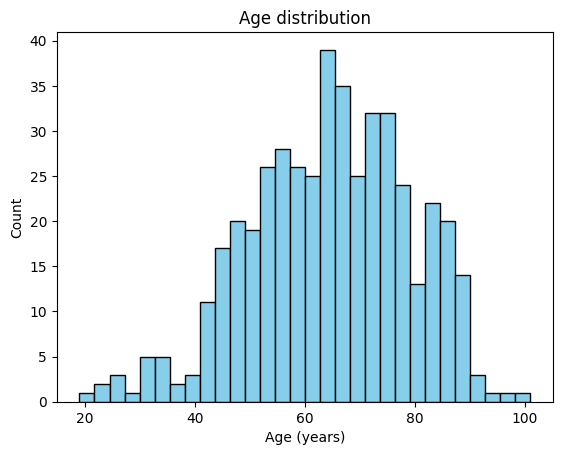

In [7]:
plot_age_histogram(development_df['age'])

### Age Distribution — All Splits

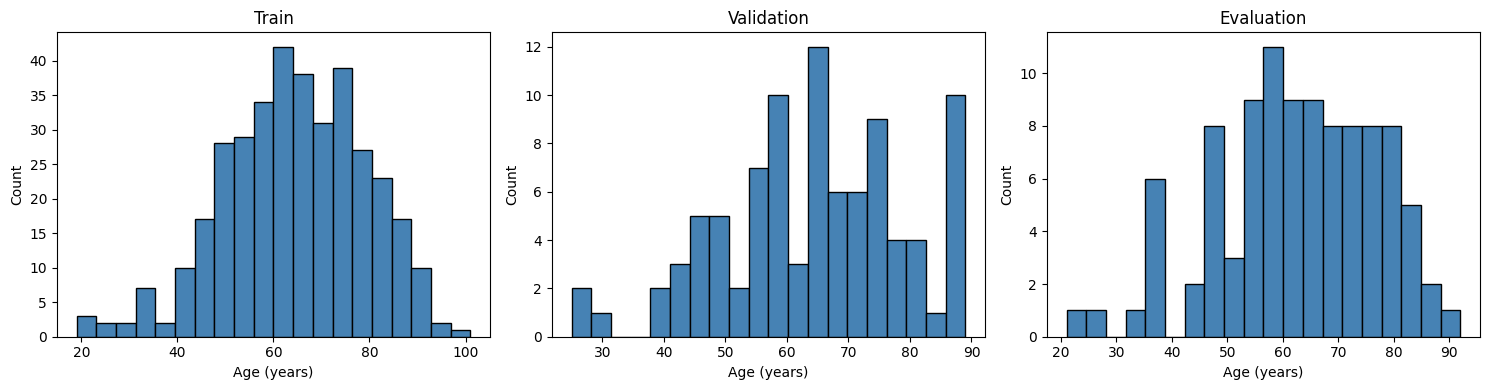

In [8]:
plot_age_by_split(train_df, val_df, evaluation_df)

### Summary of data
Basic descriptive statistics were generated for the training, validation, and evaluation sets. These included the number of samples, age mean and standard deviation, age range and the distribution of sex. In addition, missing values were inspected and dataset summaries were produced for each split.We created a histogram of age  for the full development dataset and separate age distributions were also visualised for the training, validation, and evaluation sets, to better understand the target variable.  This helped confirm that the splits had a broadly similar age distribution.


In [9]:
dataset_summary(train_df, 'Training set')
dataset_summary(val_df, 'Validation set')
dataset_summary(evaluation_df, 'Evaluation set')


Dataset: Training set
Number of samples: 364
Age mean: 64.51
Age std: 14.64
Age range: 19 - 101

Sex balance:
sex
M    191
F    173
Name: count, dtype: int64

Ethnicity balance:
ethnicity
Caucasian - European    246
Hispanic - Mexican      118
Name: count, dtype: int64

Number of CpG columns: 1000
Total missing values: 10965

Dataset: Validation set
Number of samples: 92
Age mean: 64.22
Age std: 14.69
Age range: 25 - 89

Sex balance:
sex
F    51
M    41
Name: count, dtype: int64

Ethnicity balance:
ethnicity
Caucasian - European    62
Hispanic - Mexican      30
Name: count, dtype: int64

Number of CpG columns: 1000
Total missing values: 2747

Dataset: Evaluation set
Number of samples: 100
Age mean: 62.5
Age std: 14.35
Age range: 21 - 92

Sex balance:
sex
F    58
M    42
Name: count, dtype: int64

Ethnicity balance:
ethnicity
Caucasian - European    56
Hispanic - Mexican      44
Name: count, dtype: int64

Number of CpG columns: 1000
Total missing values: 3058


**Justification:** Median imputation under MCAR does not introduce bias and is robust to skewness. OneHotEncoder converts sex and ethnicity to numerical form. Three feature matrices allow comparison of demographic vs methylation signal. No additional cleaning steps were needed.

Also, while sex and ethnicity are candidate features, they are not expected to correlate strongly with chronological age. The three-way feature comparison (metadata-only, CpG-only, and all) in Task 2 will empirically confirm whether d
demographic variables contribute any additional predictive signal beyond DNA methylation.

The age distribution of the development set is approximately bell-shaped, centred around 55–65 years, with fewer samples at younger ages below 40. The per-split histograms confirm that the training, validation, and evaluation sets share a broadly similar age distribution, with all three showing a mean of approximately 62–65 years and a standard deviation of around 14 years. This consistency validates that the stratified split successfully preserved the age distribution across all splits, ensuring that no split is systematically biased toward younger or older individuals